In [1]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import colormaps
import geopandas as gpd
import numpy as np
import xarray as xr
import rioxarray as rxr
import codebase
import geodatasets
import contextily as cx

Notes:
- Neches is a triburtary of Sabine river. Number of dams is one more than the number of basins.

In [2]:
grdc_dir = "/global/scratch/users/ann_scheliga/aux_dam_datasets/GRDC_CRB/"
res_dir = "/global/scratch/users/ann_scheliga/CYGNSS_daily/time_series/"

In [3]:
res_shp = codebase.load_data.load_GRanD()
subregions_meta = gpd.read_file(grdc_dir + 'subregions.geojson')

In [4]:
site_series = pd.read_json('../dam_basin_pair.json',typ='series')

In [5]:
site_stations = gpd.read_file(grdc_dir+'site_stationbasins.geojson')
site_stations.set_index(site_stations['grdc_no'].astype(int),inplace=True)

In [6]:
dam_names = [item.replace('_',' ') for item in list(site_series)]
dam_shps = res_shp[res_shp['DAM_NAME'].str.lower().isin(dam_names)]

## Create panel of maps

In [7]:
site_stations['lat_lon'] = gpd.points_from_xy(y =site_stations['lat_org'], x =  site_stations['long_org'])
stations_points = site_stations.set_geometry('lat_lon', crs = "EPSG:4326")

In [8]:
cmap_colors = colormaps['tab20'].colors

basin_green = (*cmap_colors[5],0.7)
res_blue = cmap_colors[0]
station_orange = cmap_colors[6]

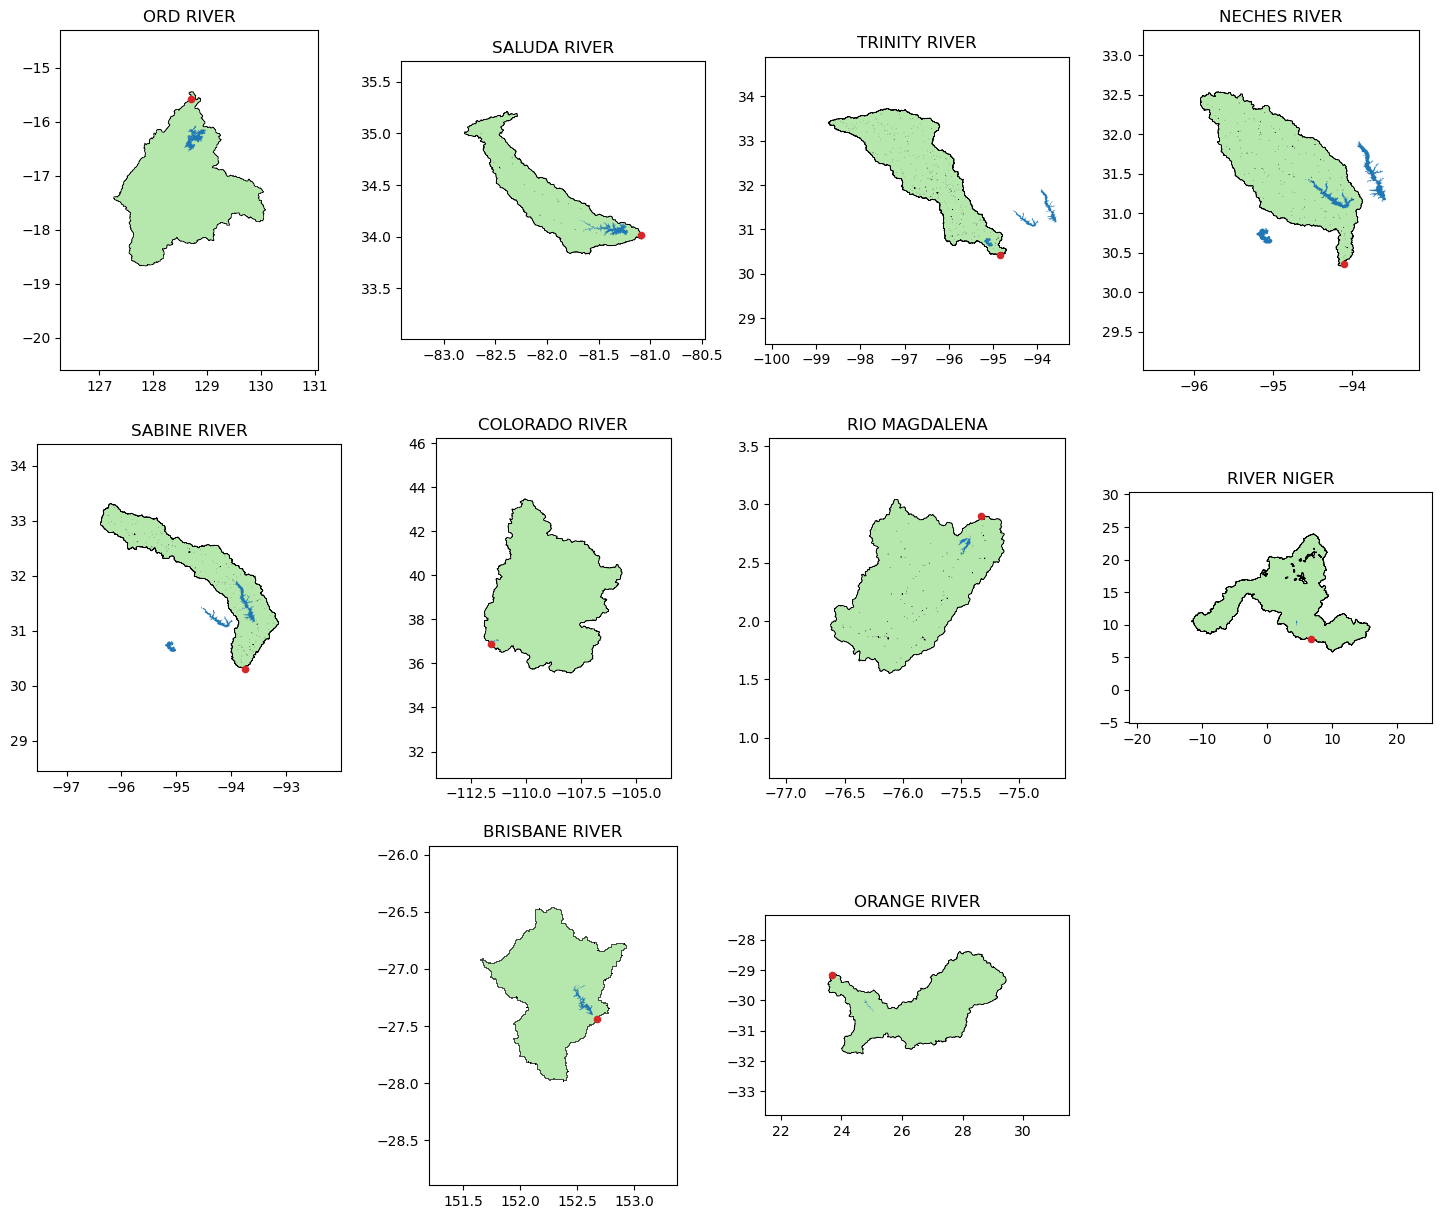

In [14]:
fig = plt.figure(figsize=(18,15))

for idx in range(len(site_stations)):
    if idx < 8:
        sub_pos = idx+1
    else:
        sub_pos= idx+2
    ax = fig.add_subplot(3,4,sub_pos)

    basin_bbox = site_stations.iloc[[idx],:].bounds.values[0]
    x_span = basin_bbox[2] - basin_bbox[0]
    y_span = basin_bbox[3] - basin_bbox[1]
    ax.set_xlim([basin_bbox[0]-x_span*0.35,basin_bbox[2]+x_span*0.35])
    ax.set_ylim([basin_bbox[1]-y_span*0.6,basin_bbox[3]+y_span*0.35])

    site_stations.iloc[[idx],:].plot(ax=ax,color=basin_green,edgecolor='black',linewidth=0.5)
    stations_points.iloc[[idx],:].plot(ax=ax,color=station_orange,edgecolor=station_orange,markersize=20)
    dam_shps.plot(ax=ax, color= res_blue)

    # cx.add_basemap(ax,crs=site_stations.crs)
    # cx.add_basemap(ax,crs=site_stations.crs, source=cx.providers.CartoDB.PositronOnlyLabels,zoom=10)
    # set the plot title
    plt.title(site_stations.iloc[idx,:]['river'])
# plt.savefig('./panel_grdc_basin_map.png')